<a href="https://colab.research.google.com/github/reddolivia/data-science-practice/blob/main/intoLeNetCIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# LeNet - CIFAR10 - DeepLearning

In [2]:
"""
Meta-data of the dataset
tihs is a 500000 32x32 color training images and 10000 test images, labels
Each training & test examples is assigned to one of the following classes:
        airplane
        automobile
        bird
        cat
        deer
        dog
        frog
        horse
        ship
        truck
"""

'\nMeta-data of the dataset\ntihs is a 500000 32x32 color training images and 10000 test images, labels\nEach training & test examples is assigned to one of the following classes:\n        airplane\n        automobile\n        bird\n        cat\n        deer\n        dog\n        frog\n        horse\n        ship\n        truck\n'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


In [4]:
# Downloading the dataset
cifar10 = tf.keras.datasets.cifar10
(xtrain , ytrain), (xtest, ytest) = cifar10.load_data()

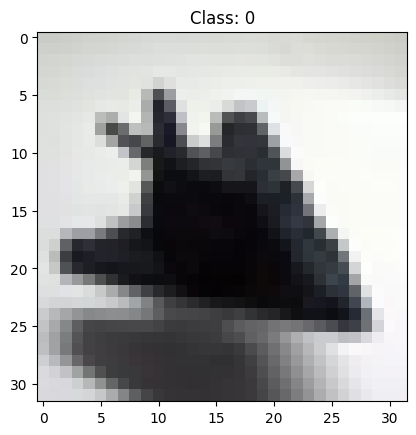

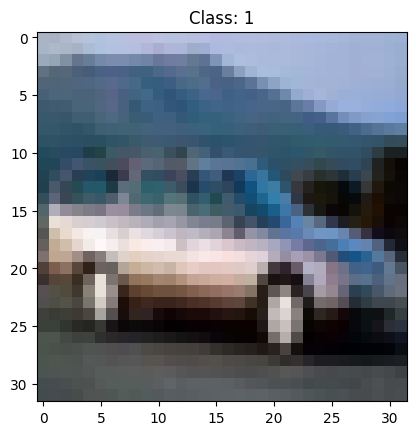

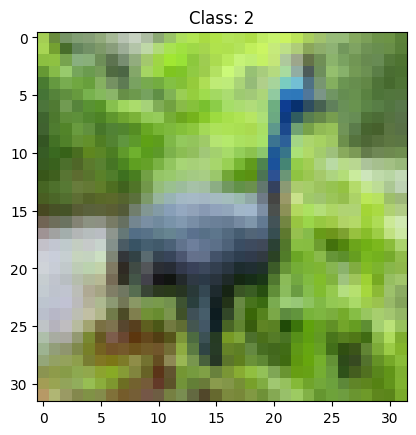

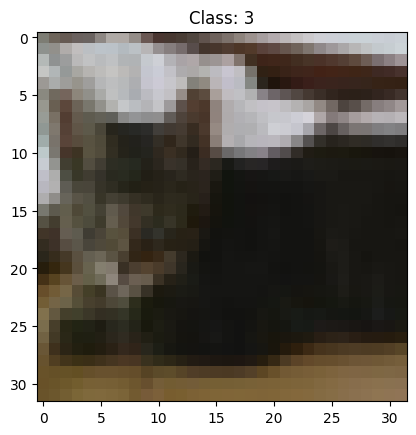

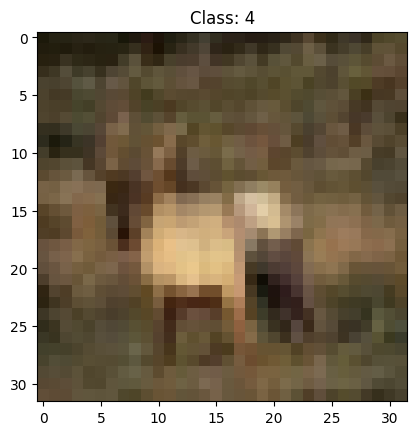

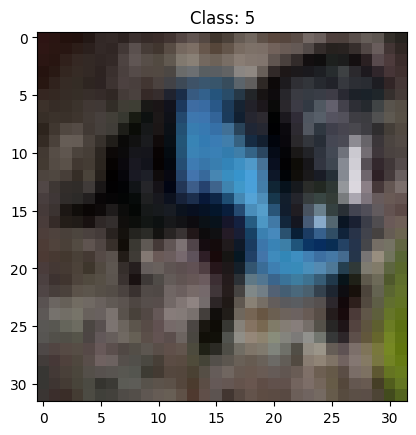

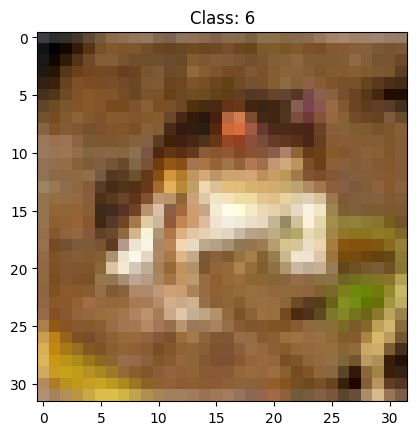

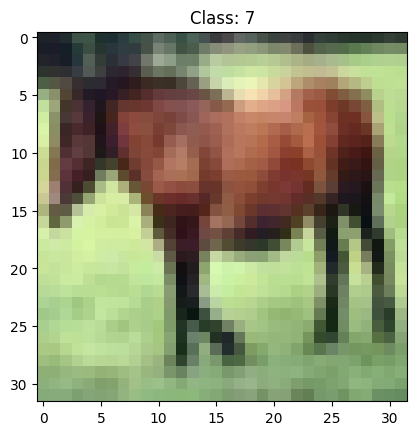

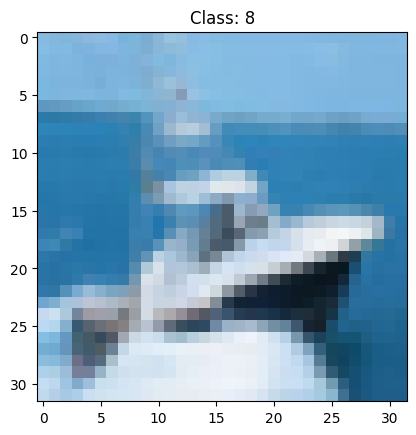

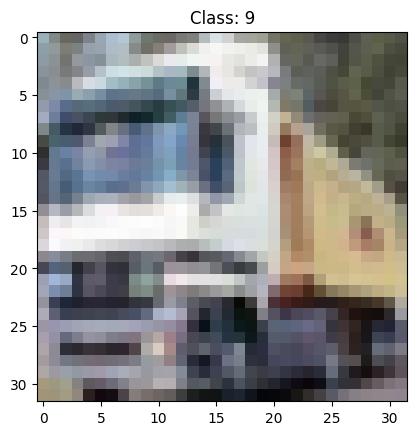

In [5]:
# printing an image from each class
for i in range(0,10):
  plt.figure(i)
  plt.title(str.format('Class: {}', i))
  im = plt.imshow(xtrain[np.where(ytrain==i)[0][0]])

In [6]:
#  1. Normalize data

xtrain_norm = xtrain / 255
xtest_norm = xtest / 255

# 2. Define Data Augmentation function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_crop(image, size = [32,32,3])
    return image, label

# 3. Create train dataloader
train_dataset = tf.data.Dataset.from_tensor_slices((xtrain_norm, ytrain))
train_dataset = (
    train_dataset
    .shuffle(buffer_size = 50000)
    .map(augment, num_parallel_calls = tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Create test dataloader
test_dataset = (
    tf.data.Dataset.from_tensor_slices((xtest_norm, ytest))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


**LeNet-5**

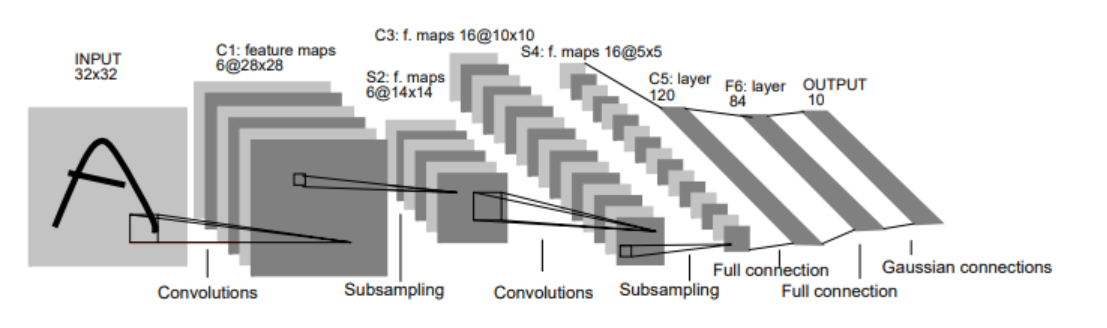

In [7]:
from keras.src import metrics
#  ---------------BUILDING MODEL------------

from keras import layers, models

# 1. Data Augmentation in model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1)
])

# 2. LeNet Model
model = models.Sequential([
            layers.Input((32,32,3)),

            # Apply Augmentation irectly insde the model
            data_augmentation,

            # Rescale pixels values [0, 255] -> [0,1]
            #layers.Rescaling(1./255),

            # conv1: Block1 -> f32 ->  Relu ->  BatchNormalization
            layers.Conv2D(filters = 32,kernel_size = (3,3), padding = 'same', activation = 'relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(pool_size = (2,2)),


            # Conv2: Block2 -> f64 -> ReLU -> BatchNormalization
            layers.Conv2D(filters = 64, kernel_size = (3,3), padding = 'same', activation = 'relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size = (2,2)),


            # Dense / Fullt connected Layers
            layers.Flatten(),
            layers.Dense(128, activation = 'relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),                # prevents overfitting
            layers.Dense(10, activation = 'softmax')

        ])


In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Compile the model

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

history = model.fit(
    train_dataset,
    epochs = 12,
    validation_data = test_dataset
)

Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.4354 - loss: 1.6348 - val_accuracy: 0.5366 - val_loss: 1.3284
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.5586 - loss: 1.2490 - val_accuracy: 0.5491 - val_loss: 1.3650
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5946 - loss: 1.1483 - val_accuracy: 0.5839 - val_loss: 1.2369
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6181 - loss: 1.0892 - val_accuracy: 0.6202 - val_loss: 1.1005
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6347 - loss: 1.0485 - val_accuracy: 0.6493 - val_loss: 0.9982
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6445 - loss: 1.0131 - val_accuracy: 0.6931 - val_loss: 0.8687
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6581 - loss: 0.9863 - val_accuracy: 0.6844 - val_loss: 0.9348
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6657 -

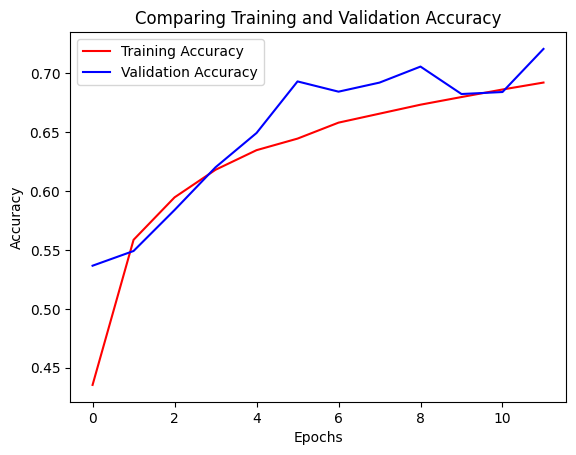

In [10]:
# Etracting models accuracy against epochs

ta = history.history['accuracy']
va = history.history['val_accuracy']
epochs  = range(len(ta))

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'r', label = 'Training Accuracy')
plt.plot(epochs, va, 'b', label = 'Validation Accuracy')
plt.title('Comparing Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

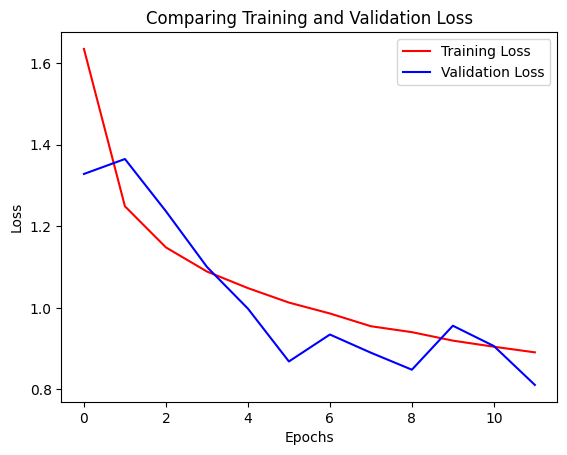

In [11]:
# Etracting models loss against epochs

tl = history.history['loss']
vl = history.history['val_loss']
epochs  = range(len(tl))

# plotting the accuracies
plt.figure()
plt.plot(epochs, tl, 'r', label = 'Training Loss')
plt.plot(epochs, vl, 'b', label = 'Validation Loss')
plt.title('Comparing Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
# obtaining the predictions
pred = np.argmax(model.predict(xtest), axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [13]:
# Evaluate using test_dataset
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Accuracy on Test Set: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7207 - loss: 0.8112
Accuracy on Test Set: 72.07%


In [14]:
# priting the clasification report
from sklearn.metrics import classification_report
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

           0       0.50      0.52      0.51      1000
           1       0.78      0.51      0.62      1000
           2       1.00      0.00      0.00      1000
           3       0.55      0.05      0.09      1000
           4       0.00      0.00      0.00      1000
           5       0.27      0.75      0.39      1000
           6       0.88      0.02      0.04      1000
           7       0.50      0.72      0.59      1000
           8       0.29      0.93      0.44      1000
           9       0.80      0.57      0.67      1000

    accuracy                           0.41     10000
   macro avg       0.56      0.41      0.34     10000
weighted avg       0.56      0.41      0.34     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


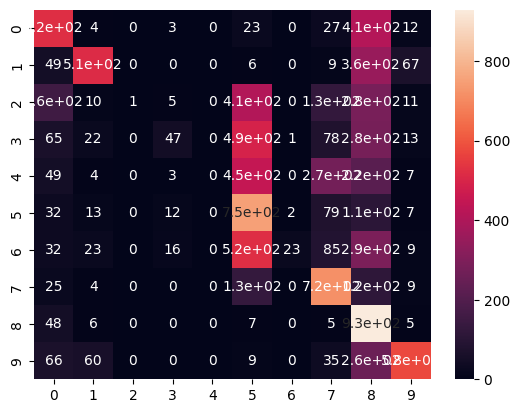

In [15]:
# plotting the confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(ytest, pred), annot = True)
plt.show()

In [16]:
pred = np.argmax(model.predict(xtest), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [17]:
pred1 = np.argmax(model.predict(xtest_norm), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [18]:
print(classification_report(ytest.flatten(), pred))

              precision    recall  f1-score   support

           0       0.50      0.52      0.51      1000
           1       0.78      0.51      0.62      1000
           2       1.00      0.00      0.00      1000
           3       0.55      0.05      0.09      1000
           4       0.00      0.00      0.00      1000
           5       0.27      0.75      0.39      1000
           6       0.88      0.02      0.04      1000
           7       0.50      0.72      0.59      1000
           8       0.29      0.93      0.44      1000
           9       0.80      0.57      0.67      1000

    accuracy                           0.41     10000
   macro avg       0.56      0.41      0.34     10000
weighted avg       0.56      0.41      0.34     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print(classification_report(ytest.flatten(), pred1))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      1000
           1       0.79      0.89      0.84      1000
           2       0.72      0.51      0.60      1000
           3       0.60      0.48      0.53      1000
           4       0.79      0.52      0.63      1000
           5       0.70      0.59      0.64      1000
           6       0.64      0.86      0.74      1000
           7       0.72      0.83      0.77      1000
           8       0.79      0.86      0.83      1000
           9       0.74      0.88      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



so its clear that normalized xtrain dataset provides a lot more improved accuracy